# Proyecto de primer corte: Fundamentos Probabilísticos del Machine Learning
**Juliana Andrea Reyes Barrios**

Dataset usado: `Credit Card Fraud Detection`

## 0. Librerías

In [1]:
# Librerías necesarias para el desarrollo del análisis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

## 1. Carga, exploración inicial y preprocesamiento de los datos

**Carga:**

In [46]:
df = pd.read_csv("creditcard.csv") # Carga del dataset
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


**Exploración inicial:**

In [47]:
df.shape # Cantidad de filas y columnas

(284807, 31)

In [50]:
df.info() # Tipo de dato de cada columna y cantidad de registros no nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [52]:
print("Valores nulos por columna:")
print(df.isnull().sum()) # Cantidad de valores nulos en cada columna

Valores nulos por columna:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [54]:
df.describe().round(5) # Estadística descriptiva de cada columna

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.00000,284807.00000,284807.00000,284807.00000,284807.00000,284807.00000,284807.00000,284807.00000,284807.00000,284807.00000,...,284807.00000,284807.00000,284807.00000,284807.00000,284807.00000,284807.00000,284807.00000,284807.00000,284807.00000,284807.00000
mean,94813.85958,0.00000,0.00000,-0.00000,0.00000,0.00000,0.00000,-0.00000,0.00000,-0.00000,...,0.00000,-0.00000,0.00000,0.00000,0.00000,0.00000,-0.00000,-0.00000,88.34962,0.00173
std,47488.14595,1.95870,1.65131,1.51626,1.41587,1.38025,1.33227,1.23709,1.19435,1.09863,...,0.73452,0.72570,0.62446,0.60565,0.52128,0.48223,0.40363,0.33008,250.12011,0.04153
min,0.00000,-56.40751,-72.71573,-48.32559,-5.68317,-113.74331,-26.16051,-43.55724,-73.21672,-13.43407,...,-34.83038,-10.93314,-44.80774,-2.83663,-10.29540,-2.60455,-22.56568,-15.43008,0.00000,0.00000
25%,54201.50000,-0.92037,-0.59855,-0.89036,-0.84864,-0.69160,-0.76830,-0.55408,-0.20863,-0.64310,...,-0.22839,-0.54235,-0.16185,-0.35459,-0.31715,-0.32698,-0.07084,-0.05296,5.60000,0.00000
50%,84692.00000,0.01811,0.06549,0.17985,-0.01985,-0.05434,-0.27419,0.04010,0.02236,-0.05143,...,-0.02945,0.00678,-0.01119,0.04098,0.01659,-0.05214,0.00134,0.01124,22.00000,0.00000
75%,139320.50000,1.31564,0.80372,1.02720,0.74334,0.61193,0.39856,0.57044,0.32735,0.59714,...,0.18638,0.52855,0.14764,0.43953,0.35072,0.24095,0.09105,0.07828,77.16500,0.00000
max,172792.00000,2.45493,22.05773,9.38256,16.87534,34.80167,73.30163,120.58949,20.00721,15.59499,...,27.20284,10.50309,22.52841,4.58455,7.51959,3.51735,31.61220,33.84781,25691.16000,1.00000


In [56]:
# Distribución de las clases de la variable objetivo
conteo_clases = df["Class"].value_counts().sort_index()
porcentaje_clases = df["Class"].value_counts(normalize=True).sort_index() * 100

resumen_clases = pd.DataFrame({
    "Cantidad: ": conteo_clases,
    "Porcentaje: ": porcentaje_clases.round(5)
})

resumen_clases

,Cantidad:,Porcentaje:
Class,,
0,284315,99.82725
1,492,0.17275


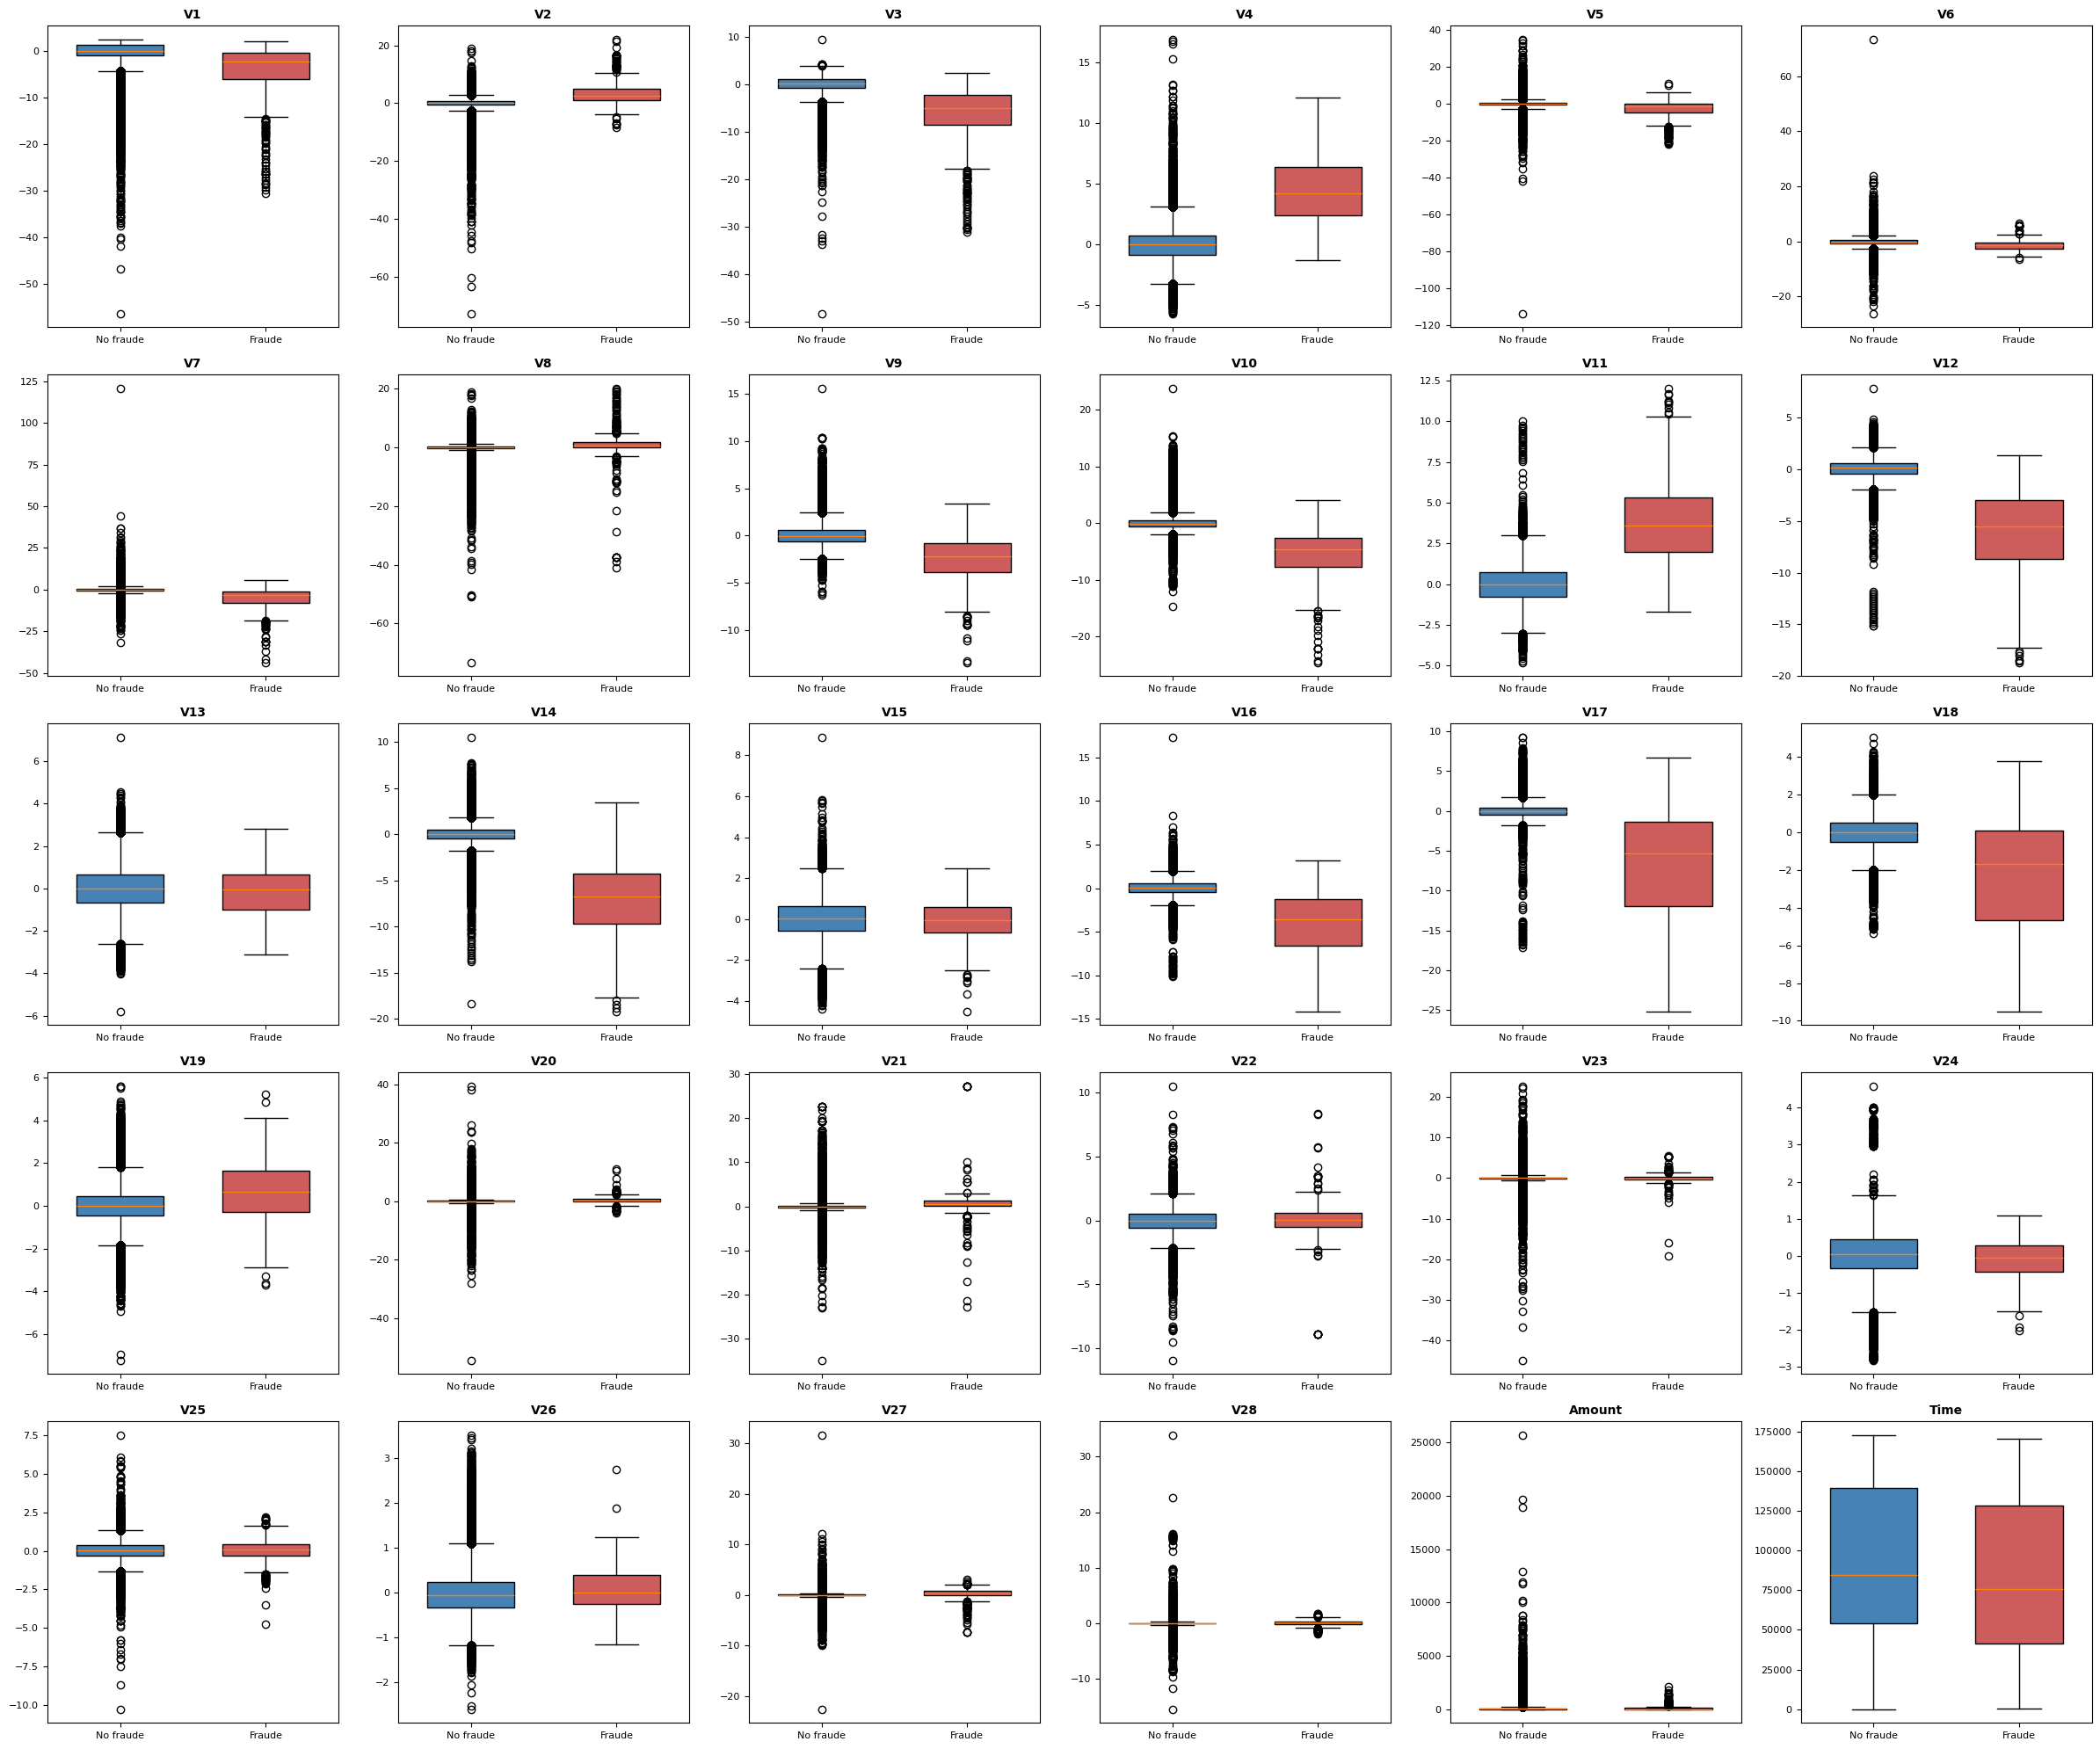

In [58]:
# Boxplot de la distribución de cada variable predictora, separado entre Fraude y No fraude
cols = [f'V{i}' for i in range(1, 29)] + ['Amount', 'Time'] # Seleccionar solo las variables predictoras

n_cols = 6
n_rows = int(np.ceil(len(cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 20))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    data_0 = df[df['Class'] == 0][col]
    data_1 = df[df['Class'] == 1][col]
    bp = ax.boxplot([data_0, data_1], tick_labels=['No fraude', 'Fraude'],
                     patch_artist=True, showfliers=True, widths=0.6)
    bp['boxes'][0].set_facecolor('steelblue') # Azul: No fraude
    bp['boxes'][1].set_facecolor('indianred') # Rojo: Fraude
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.tick_params(labelsize=8)

for j in range(len(cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Los resultados de esta exploración permiten observar que:

- El dataset tiene 284.807 filas y 31 columnas
- Todas las variables predictoras son del tipo float, y la variable objetivo `Class` es de tipo integer
- El dataset no tiene datos nulos
- Las clases de la variable objetivo tienen un gran desbalance, con solo 492 casos de fraude registrado frente a 284.315 casos en los que no
- La distribución de las variables cambia mucho, y no se observa algún patrón

## 2. Preguntas de negocio a responder

#### 2.1 Probabilidad condicional
- ¿Qué tan más probable es que una transacción sea fraude cuando su monto supera cierto umbral?
- ¿Le sirve a la red usar solo el monto como señal de alerta?

#### 2.2 Teorema de Bayes
- Si activamos una alerta basada en una señal simple (ej. V14 por debajo de cierto valor), ¿cuál es la probabilidad real de que la transacción sea fraude, dado que el fraude es solo el 0.172% de los casos?

#### 2.3 Verosimilitud / MLE
- ¿Qué parámetros (media, desviación) describen mejor el comportamiento de la componente V14 en transacciones fraudulentas vs. legítimas?
- ¿Qué tan distintos son esos dos "perfiles" estadísticos?

#### 2.4 Distribuciones paramétricas
- ¿Se puede modelar el comportamiento de las componentes PCA con una distribución Gaussiana, o su forma real se aleja de ese supuesto?
- ¿Qué implica eso para un sistema de detección basado en umbrales?

#### 2.5 Esperanza y varianza
- ¿El monto promedio de una transacción fraudulenta es distinto al de una legítima?
- ¿Cuál de las dos poblaciones es más impredecible (mayor varianza)?

#### 2.6 Independencia y correlación
- ¿Están las componentes PCA correlacionadas entre sí (como se espera por diseño), y qué tan relacionado está el monto y tiempo de la transacción con que sea fraude?

#### 2.7 Prior y posterior
- Si la red confía ciegamente en un clasificador con alta precisión, ¿qué tan engañosa es esa cifra dado lo raro que es el fraude? ¿Cómo cambia la creencia de fraude antes y después de ver la evidencia?

#### 2.8 Entropía
- ¿Qué tan impredecible es la variable Class en este dataset?
- ¿Ese nivel de incertidumbre oculta el verdadero reto de detectar los pocos casos de fraude?

#### 2.9 Entropía cruzada
- ¿Qué tan bien predice un modelo simple la probabilidad de fraude, y cómo cambia esa calidad de predicción si corregimos el desbalance de clases?

#### 2.10 Divergencia KL
- ¿Cuál de las 28 componentes PCA separa mejor las transacciones fraudulentas de las legítimas?
- ¿Cómo se traduce eso en una recomendación de qué variables monitorear?

## 3. Análisis para cada concepto
#### 3.1 Probabilidad condicional

In [90]:
print("1. Probabilidad condicional")
umbrales = [10, 50, 200, 1000, 10000] # Valores que amount puede adoptar

for u in umbrales:
    subset = df[df['Amount'] > u] # Seleccionar solo los casos en los que amount es superior al umbral
    p_fraude_dado_monto = subset['Class'].mean() # Obtener el promedio de Class en esos casos
    print(f"P(fraude | Amount > {u}) = {p_fraude_dado_monto:.5f}  (n={len(subset)})") 

1. Probabilidad condicional
P(fraude | Amount > 10) = 0.00132  (n=184543)
P(fraude | Amount > 50) = 0.00198  (n=93762)
P(fraude | Amount > 200) = 0.00295  (n=28837)
P(fraude | Amount > 1000) = 0.00306  (n=2940)
P(fraude | Amount > 10000) = 0.00000  (n=7)


Al aumentar el umbral, se observa una disminución en la probabilidad de que haya fraude, es decir, los fraudes no se concentran en montos altos.

#### 3.2 Teorema de Bayes

In [60]:
print("2. Teorema de Bayes")
prior_fraude = df['Class'].mean() # El prior es el promedio de Class
umbral_v14 = -6 # Se toma el umbral -6
df['test_positivo'] = df['V14'] < umbral_v14 # El test es positivo si el valor de V14 es menor al umbral

p_test_dado_fraude = df[df['Class'] == 1]['test_positivo'].mean() # sensibilidad
p_test_dado_no_fraude = df[df['Class'] == 0]['test_positivo'].mean() # tasa de falsos positivos
p_test_positivo = df['test_positivo'].mean() # probabilidad de que el test sea positivo

# Bayes: P(fraude | test+) = P(test+ | fraude) * P(fraude) / P(test+)
p_fraude_dado_test = (p_test_dado_fraude * prior_fraude) / p_test_positivo

print(f"Prior P(fraude) = {prior_fraude:.5f}")
print(f"P(test+ | fraude) = {p_test_dado_fraude:.4f}")
print(f"P(test+ | no fraude) = {p_test_dado_no_fraude:.4f}")
print(f"POSTERIOR P(fraude | test+) = {p_fraude_dado_test:.4f}")
print(f"La evidencia multiplica la probabilidad de fraude x{p_fraude_dado_test/prior_fraude:.0f}")

2. Teorema de Bayes
Prior P(fraude) = 0.00173
P(test+ | fraude) = 0.5772
P(test+ | no fraude) = 0.0004
POSTERIOR P(fraude | test+) = 0.7030
La evidencia multiplica la probabilidad de fraude x407


Al implementar un umbral de V14 < -6 para marcar una transacción como sospechosa y usando el prior de 0,173%, se detecta al 57,7% de los fraudes reales y solo marca de manera errónea al 0,04% de las transacciones legítimas. 

Usando Bayes se obtiene que, dado que la señal se activó, la probabilidad real de que sea fraude sube a 70,3%, por lo que la evidencia multiplica la probabilidad de fraude por 407 veces.

#### 3.3 Verosimilitud / MLE

In [66]:
print("3. Verosimilitud / MLE")
v14_no_fraude = df[df['Class'] == 0]['V14'] # Toma la columna V14 de las transacciones no fraudulentas
v14_fraude = df[df['Class'] == 1]['V14'] # Toma la columna V14 de las transacciones fraudulentas

# Se usa stats.norm.fit para hacer el MLE y encontrar los parámetros que maximizan la verosimilitud
mu0, sigma0 = stats.norm.fit(v14_no_fraude)
mu1, sigma1 = stats.norm.fit(v14_fraude)

print(f"No fraude: mu_MLE={mu0:.3f}, sigma_MLE={sigma0:.3f}")
print(f"Fraude:    mu_MLE={mu1:.3f}, sigma_MLE={sigma1:.3f}")
print(f"Diferencia de medias: {mu0 - mu1:.3f}")

3. Verosimilitud / MLE
No fraude: mu_MLE=0.012, sigma_MLE=0.897
Fraude:    mu_MLE=-6.972, sigma_MLE=4.275
Diferencia de medias: 6.984


Las transacciones legítimas tienen un comportamiento centrado casi en cero y con dispersión moderada, mientras que las transacciones fraudulentas están centradas en un valor desplazado hacia los valores negativos y tienen una dispersión casi 5 veces mayor que las transacciones legítimas.

#### 3.4 Distribuciones paramétricas

In [72]:
print("4. Distribuciones paramétricas")
componentes_a_evaluar = ['V17', 'V12', 'V16']  # las componentes más informativas (ver punto 10)

for col in componentes_a_evaluar:
    x = df[col].values
    mu, sigma = stats.norm.fit(x) # Ajustar los parámetros de la gaussiana
    # Kolmogorov-Smirnov: contraste numérico de qué tan bien ajusta la Gaussiana
    ks_stat, ks_p = stats.kstest(x, 'norm', args=(mu, sigma))
    print(f"{col}: Gaussiana MLE -> mu={mu:.3f}, sigma={sigma:.3f} | KS={ks_stat:.4f}, p={ks_p:.2e}")

4. Distribuciones paramétricas
V17: Gaussiana MLE -> mu=-0.000, sigma=0.849 | KS=0.0749, p=0.00e+00
V12: Gaussiana MLE -> mu=-0.000, sigma=0.999 | KS=0.0936, p=0.00e+00
V16: Gaussiana MLE -> mu=0.000, sigma=0.876 | KS=0.0491, p=0.00e+00


An las tres componentes se rechaza el ajuste Gaussiano perfecto, es decir, aunque el parámetro $\mu$ sale prácticamente en 0 para las tres, la forma real de estas distribuciones se aleja significativamente de una campana Gaussiana.

V16 es la que mejor se aproxima a una Gaussiana de las tres (el KS más bajo), seguido del V17 y por último el V12.

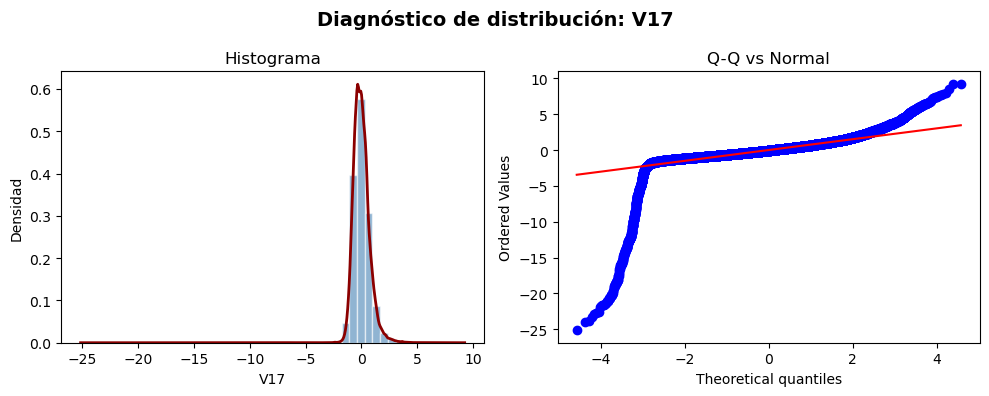

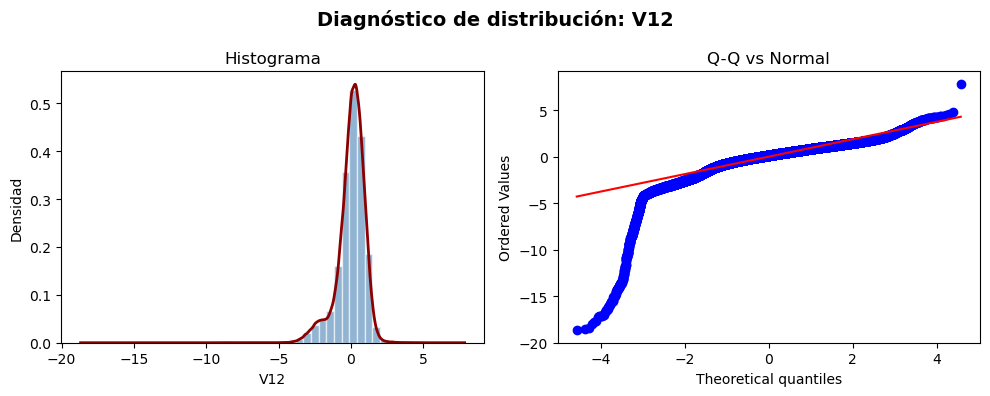

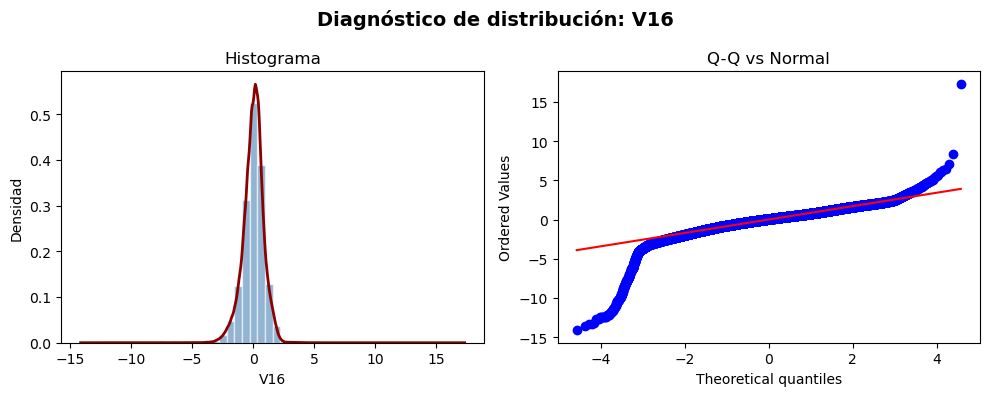

In [73]:
# Gráficos: histogramas y Q-Q plots para los 3 componentes más informativos
def plot_variable_diagnostics(data, col):
    x = data[col].dropna().values

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(f'Diagnóstico de distribución: {col}', fontsize=14, fontweight='bold')

    # Histograma
    axes[0].hist(x, bins=50, density=True, alpha=0.6, color='steelblue', edgecolor='white')
    kde = stats.gaussian_kde(x)
    x_range = np.linspace(x.min(), x.max(), 500)
    axes[0].plot(x_range, kde(x_range), color='darkred', linewidth=2)
    axes[0].set_title('Histograma')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Densidad')

    # Q-Q plot vs Normal
    stats.probplot(x, dist='norm', plot=axes[1])
    axes[1].set_title('Q-Q vs Normal')

    plt.tight_layout()
    plt.show()

for col in componentes_a_evaluar:
    plot_variable_diagnostics(df, col)

En los 3 casos, el p-valor es 0, por lo que se rechaza el ajuste Gaussiano perfecto. Además, esto coincide con las colas pesadas vistas en los Q-Q plots.

#### 3.5 Esperanza y varianza

In [74]:
print("5. Esperanza y Varianza de Amount")
amount_no_fraude = df[df['Class'] == 0]['Amount'] # Montos de los registros sin fraude
amount_fraude = df[df['Class'] == 1]['Amount'] # Montos de los registros de fraude

# Media y varianza de cada grupo
print(f"No fraude: E[Amount]={amount_no_fraude.mean():.2f}, Var[Amount]={amount_no_fraude.var():.2f}")
print(f"Fraude:    E[Amount]={amount_fraude.mean():.2f}, Var[Amount]={amount_fraude.var():.2f}")
# Mediana de los grupos
print(f"Mediana no fraude: {amount_no_fraude.median():.2f} | Mediana fraude: {amount_fraude.median():.2f}")

5. Esperanza y Varianza de Amount
No fraude: E[Amount]=88.29, Var[Amount]=62552.56
Fraude:    E[Amount]=122.21, Var[Amount]=65886.31
Mediana no fraude: 22.00 | Mediana fraude: 9.25


Tanto la esperanza como la varianza de los registros legítimos son menores, lo que indican que están más concentrados y su centro se encuentra más cerca a cero (también se ve en la mediana). Los registros de fraude son más variables ligeramente y parece haber valores atípicos altos que elevan el valor de su media y lo alejan de la mediana.

#### 3.6 Independencia y correlación

In [75]:
print("6. Independencia y Correlación")
v_cols = [f'V{i}' for i in range(1, 29)] # Columnas a usar (componentes del V1 al V28)
corr_v = df[v_cols].corr().to_numpy(copy=True) # Calcular la correlación de Pearson entre todas las componentes
np.fill_diagonal(corr_v, np.nan) # Dejar la diagonal de la matriz con NaN
print(f"Correlación máxima absoluta entre pares de V1...V28: {np.nanmax(np.abs(corr_v)):.6f}")

corr_amount_class = df['Amount'].corr(df['Class']) # Correlación de Pearson entre Amount y Class
corr_time_class = df['Time'].corr(df['Class']) # Correlación de Pearson entre Time y Class
print(f"Correlación Amount vs Class: {corr_amount_class:.4f}")
print(f"Correlación Time vs Class:   {corr_time_class:.4f}")

6. Independencia y Correlación
Correlación máxima absoluta entre pares de V1...V28: 0.000000
Correlación Amount vs Class: 0.0056
Correlación Time vs Class:   -0.0123


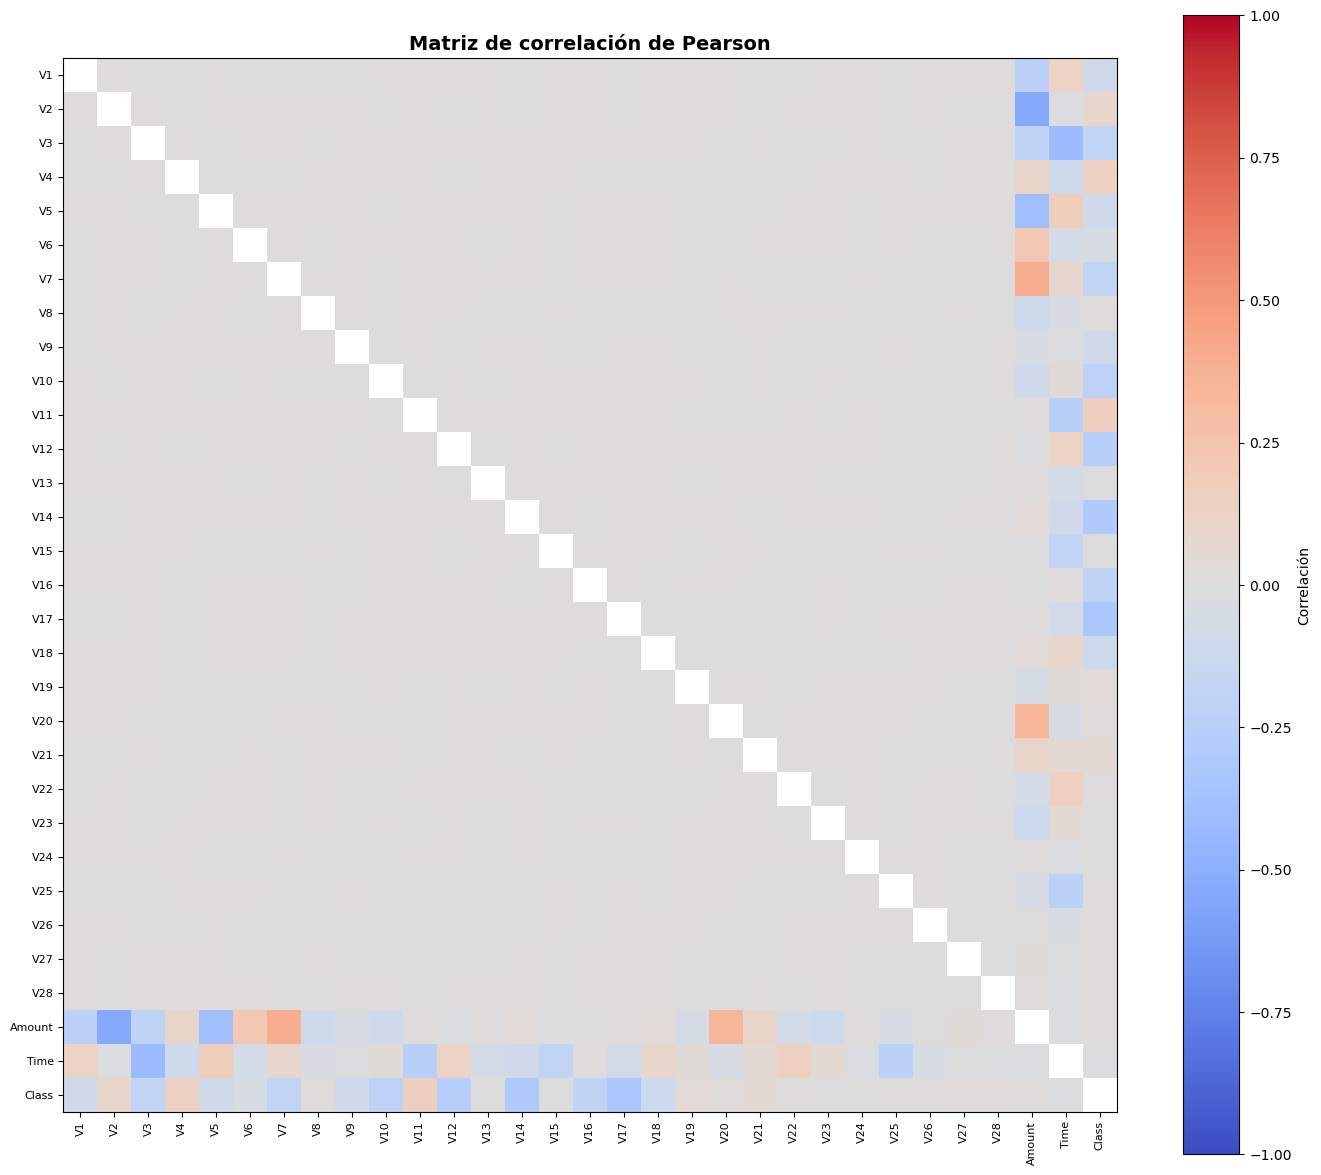

In [76]:
# Columnas originales del dataset (excluye variables creadas durante el análisis, como test_positivo)
cols_originales = [f'V{i}' for i in range(1, 29)] + ['Amount', 'Time', 'Class']

# Matriz de correlación de Pearson
corr_pearson = df[cols_originales].corr(method='pearson')
# Diagonal principal en NaN
corr_array = corr_pearson.to_numpy(copy=True)
np.fill_diagonal(corr_array, np.nan)
corr_pearson = pd.DataFrame(corr_array, index=corr_pearson.index, columns=corr_pearson.columns)

def plot_corr_matrix(corr, title, save_path=None):
    fig, ax = plt.subplots(figsize=(14, 12))
    im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
    ax.set_yticklabels(corr.columns, fontsize=8)
    plt.colorbar(im, ax=ax, label='Correlación')
    ax.set_title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_corr_matrix(corr_pearson, 'Matriz de correlación de Pearson')

Al tener la correlación máxima absoluta entre pares en 0, se confirma el diseño ortogonal del PCA. Así mismo, se observa que `Amount` y `Time` no son indicadores fuertes de fraude por sí mismos.

#### 3.7 Prior y posterior

In [77]:
print("7. Prior y Posterior")
prior = df['Class'].mean() # Promedio de Class (proporción de fraudes)
sensibilidad = 0.99   # P(alerta | fraude real)
especificidad = 0.99  # P(no alerta | no fraude real)
fp_rate = 1 - especificidad # Tasa de falsos positivos

# Probabilidad de que el sistema arroje una alerta, sin importar si es fraude o no
p_alerta = sensibilidad * prior + fp_rate * (1 - prior)
# Teorema de Bayes: ¿Si hay alerta, qué tan probable es que sea fraude?
posterior = (sensibilidad * prior) / p_alerta

print(f"Prior P(fraude) = {prior:.5f} ({prior*100:.3f}%)")
print(f"Clasificador simulado con sensibilidad = 99% y especificidad = 99%")
print(f"POSTERIOR real P(fraude | alerta) = {posterior:.4f} ({posterior*100:.1f}%)")
print(f"-> Por cada fraude real detectado hay ~{(1-posterior)/posterior:.0f} falsas alarmas.")

7. Prior y Posterior
Prior P(fraude) = 0.00173 (0.173%)
Clasificador simulado con sensibilidad = 99% y especificidad = 99%
POSTERIOR real P(fraude | alerta) = 0.1463 (14.6%)
-> Por cada fraude real detectado hay ~6 falsas alarmas.


Al aplicar el teorema de Bayes usando el prior de 0,173%, la probabilidad de que una transacción marcada como fraude lo sea realmente cae a 14,6%. A pesar de que el clasificador parece muy preciso, la posterior muestra que por cada fraude real detectado hay más o menos 6 falsas alarmas.

#### 3.8 Entropía

In [78]:
print("8. Entropía")
p_fraude = df['Class'].mean()  # Proporción de fraudes
p_no_fraude = 1 - p_fraude     # Proporción de no fraudes

# Cálculo de la entropía real de Class
entropia_class = -(p_fraude*np.log2(p_fraude) + p_no_fraude*np.log2(p_no_fraude))

# Cálculo de la entropía máxima posible: ocurre cuando p=0.5
p_max = 0.5
entropia_max = -(p_max*np.log2(p_max) + (1-p_max)*np.log2(1-p_max))

print(f"Entropía de Class = {entropia_class:.5f} bits")
print(f"Entropía máxima posible (con p=0.5) = {entropia_max:.5f} bits")

8. Entropía
Entropía de Class = 0.01834 bits
Entropía máxima posible (con p=0.5) = 1.00000 bits


La entropía es muy baja, lo cual se puede atribuir al desbalance de clases. Ya que predecir siempre que no hay fraude es casi correcto, se oculta la dificultad real de encontrar los pocos casos de fraude.

#### 3.9 Entropía cruzada

In [79]:
print("9. Entropía cruzada")

# Separar variables predictoras y objetivo
X = df.drop(columns=['Class', 'test_positivo'])
y = df['Class']

# Dividir en entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Escalar las variables usando los datos de entrenamiento
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Entrenar el modelo (regresión logística)
modelo = LogisticRegression(max_iter=2000, class_weight='balanced')
modelo.fit(X_train_s, y_train)

# Hacer predicciones de la probabilidad estimada de fraude con los datos de entrenamiento y prueba
proba_train = modelo.predict_proba(X_train_s)[:, 1]
proba_test = modelo.predict_proba(X_test_s)[:, 1]

# Calcular la entropía cruzada entre las etiquetas reales y las probabilidades predichas por el modelo
ce_train = log_loss(y_train, proba_train)
ce_test = log_loss(y_test, proba_test)

print(f"Entropía cruzada (train, pesos balanceados) = {ce_train:.4f} nats")
print(f"Entropía cruzada (test, pesos balanceados)  = {ce_test:.4f} nats")

9. Entropía cruzada
Entropía cruzada (train, pesos balanceados) = 0.0932 nats
Entropía cruzada (test, pesos balanceados)  = 0.0961 nats


La cercanía entre ambos valores es una buena señal de que el modelo no está sobreajustado y generaliza bien a datos que no vio durante el entrenamiento.

Cuanto más baja, mejor predice el modelo la probabilidad real de fraude.

#### 9.10 Divergencia KL

In [80]:
print("10. Divergencia KL")

# Divergencia KL para cada columna
def kl_divergence_variable(data, col, bins=50):
    # Guardar por separado los registros de fraude y no fraude
    x0 = data[data['Class'] == 0][col]
    x1 = data[data['Class'] == 1][col]
    # Encontrar el mínimo y máximo usando ambos grupos
    min_val = min(x0.min(), x1.min())
    max_val = max(x0.max(), x1.max())
    edges = np.linspace(min_val, max_val, bins + 1)
    # Construir histogramas para representar la densidad de probabilidad, y se guarda las alturas de las barras
    p, _ = np.histogram(x0, bins=edges, density=True)
    q, _ = np.histogram(x1, bins=edges, density=True)
    
    # Sumar un valor muy pequeño a todos para evitar problemas al encontrarse con log(0)
    eps = 1e-10  # Valor muy pequeño
    p = (p + eps) / (p + eps).sum()
    q = (q + eps) / (q + eps).sum()

    return stats.entropy(q, p)  # Cálculo de la divergencia KL(fraude || no_fraude)

resultados_kl = {f'V{i}': kl_divergence_variable(df, f'V{i}') for i in range(1, 29)}
kl_ordenado = sorted(resultados_kl.items(), key=lambda x: x[1], reverse=True)

print("Las 28 componentes ordenadas por divergencia KL (más informativa primero):")
for col, kl in kl_ordenado:
    print(f"  {col}: KL = {kl:.4f}")

10. Divergencia KL
Las 28 componentes ordenadas por divergencia KL (más informativa primero):
  V17: KL = 6.9069
  V12: KL = 6.7567
  V16: KL = 6.2664
  V14: KL = 6.0159
  V10: KL = 6.0104
  V11: KL = 5.3894
  V18: KL = 4.3271
  V9: KL = 3.4556
  V3: KL = 3.2858
  V4: KL = 3.0214
  V7: KL = 2.2549
  V2: KL = 1.8694
  V8: KL = 1.2420
  V5: KL = 1.1685
  V1: KL = 1.1296
  V21: KL = 1.0016
  V6: KL = 0.9575
  V27: KL = 0.9555
  V19: KL = 0.6879
  V28: KL = 0.6648
  V22: KL = 0.3809
  V23: KL = 0.2581
  V25: KL = 0.1729
  V20: KL = 0.1724
  V24: KL = 0.1335
  V26: KL = 0.1139
  V15: KL = 0.0677
  V13: KL = 0.0675


El componente más informativo es V17, seguido de V12 y V16.